# Modelling data - Version 8

This version only includes the generation variables (except SOLAR) and ENSO.

<div>
Trabajo Integrador<br>
Maestría en Analítica e Inteligencia de Negocios<br>
Universidad del Valle<br>

</div>

#### Student
Camilo Andrés Jaramillo Tarapues - 2402218 

## Libraries

In [1]:
# Libraries

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.model_selection import GridSearchCV, cross_val_score, TimeSeriesSplit
import optuna
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from prophet import Prophet
from sklearn.ensemble import ExtraTreesRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

# Metrics
from sklearn.metrics import make_scorer, r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

## Dataset

In [2]:
# Cargar el conjunto de datos
df = pd.read_csv('../../data/out/dataset_final.csv')
df

,FECHA_HORA,YEAR,MONTH,DAY,HORA,PRECIO,TERMICA,HIDRAULICA,SOLAR,COGENERADOR,...,FUEL_CONS_GAS,FUEL_CONS_GAS_NI,FUEL_CONS_GLP,FUEL_COST_CARBON,FUEL_COST_GAS,FUEL_COST_GAS_NI,FUEL_COST_COMBUSTOLEO,IPC_VAR_MOM_PCT,IPP_VAR_PN_MOM_PCT,IPP_VAR_OI_MOM_PCT
0,2020-01-01 00:00:00,2020,1,1,0,72.02,2109637.93,4418103.51,0.00,28880.74,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
1,2020-01-01 01:00:00,2020,1,1,1,136.71,1864989.80,4548853.97,0.00,29107.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
2,2020-01-01 02:00:00,2020,1,1,2,127.71,1720883.01,4525898.75,0.00,25939.87,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
3,2020-01-01 03:00:00,2020,1,1,3,127.71,1649014.61,4458645.56,0.00,25651.57,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
4,2020-01-01 04:00:00,2020,1,1,4,127.71,1711745.36,4279657.90,0.00,25245.37,...,167262.22900,0.0000,0.0,130.459523,240.075697,0.00000,585.085344,0.42,-0.73,-0.02
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48187,2025-06-30 19:00:00,2025,6,30,19,112.55,1311491.62,9025510.46,2476.26,88117.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48188,2025-06-30 20:00:00,2025,6,30,20,112.55,1316147.03,8848494.08,1550.03,93431.69,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48189,2025-06-30 21:00:00,2025,6,30,21,106.25,1376475.95,8510792.32,0.00,95167.23,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63
48190,2025-06-30 22:00:00,2025,6,30,22,105.55,1401097.29,8058142.03,0.00,99156.29,...,51659.76948,126495.9129,0.0,159.420866,817.935238,515.62897,946.613110,0.10,-0.28,-0.63


In [3]:
# Dropping column "SOLAR"

df = df.drop(columns=["YEAR", "MONTH", "DAY", "HORA", "SOLAR",
                      "FUEL_CONS_ACPM", "FUEL_CONS_CARBON", "FUEL_CONS_COMBUSTOLEO", 
                      "FUEL_CONS_CRUDO", "FUEL_CONS_GAS", "FUEL_CONS_GAS_NI", "FUEL_CONS_GLP",
                      "FUEL_COST_CARBON", "FUEL_COST_GAS", "FUEL_COST_GAS_NI", "FUEL_COST_COMBUSTOLEO",
                      "IPC_VAR_MOM_PCT", "IPP_VAR_PN_MOM_PCT", "IPP_VAR_OI_MOM_PCT"])
df.head()

,FECHA_HORA,PRECIO,TERMICA,HIDRAULICA,COGENERADOR,EOLICA,NIVEL_ENSO
0,2020-01-01 00:00:00,72.02,2109637.93,4418103.51,28880.74,4291.34,1.0
1,2020-01-01 01:00:00,136.71,1864989.80,4548853.97,29107.37,3511.94,1.0
2,2020-01-01 02:00:00,127.71,1720883.01,4525898.75,25939.87,2641.90,1.0
3,2020-01-01 03:00:00,127.71,1649014.61,4458645.56,25651.57,3032.30,1.0
4,2020-01-01 04:00:00,127.71,1711745.36,4279657.90,25245.37,2514.76,1.0


In [4]:
print("Dataset info: ")
print(df.info())

Dataset info: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48192 entries, 0 to 48191
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   FECHA_HORA   48192 non-null  object 
 1   PRECIO       48192 non-null  float64
 2   TERMICA      48192 non-null  float64
 3   HIDRAULICA   48192 non-null  float64
 4   COGENERADOR  48192 non-null  float64
 5   EOLICA       48192 non-null  float64
 6   NIVEL_ENSO   48192 non-null  float64
dtypes: float64(6), object(1)
memory usage: 2.6+ MB
None


In [5]:
print("Missing values by column:")
print(df.isnull().sum())

Missing values by column:
FECHA_HORA     0
PRECIO         0
TERMICA        0
HIDRAULICA     0
COGENERADOR    0
EOLICA         0
NIVEL_ENSO     0
dtype: int64


**There are no missing values and all data is numeric, so it is ready to train the models.**

## Scale data

In [6]:
# Define target column 'PRECIO'
TARGET_COLUMN = 'PRECIO'

# Variables that are truly categorical even though they are numerical
categorical_numeric = ["NIVEL_ENSO"]

# Identify the continuous numerical columns that we do scale
numeric_features = [
    col for col in df.columns 
    if col not in categorical_numeric and col != TARGET_COLUMN and col != 'FECHA_HORA'
]

# Preprocessor: We only scale continuous numerics
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", "passthrough", categorical_numeric)
    ]
)

## Train, test and split data

Dividing the balanced dataset into two subsets: one to train the model8(70% of the data) and another to evaluate it (remainin2 30%

In [7]:
X = df.drop(columns=["FECHA_HORA", TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Split the dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Mostrar el tamaño de cada conjunto
print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (38553, 5)
Test set size: (9639, 5)


## Baseline Models

In [8]:
# Baseline models evaluation with multiple metrics

# Define dictionary of regression models
random_state=42

baseline_models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(),
    "Lasso": Lasso(),
    "ElasticNet": ElasticNet(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(n_jobs=-1, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(),  # may be slower on large datasets
    "KNN": KNeighborsRegressor(),  # may be slower on large datasets
}

# Define multiple metrics
scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error),
    "mse": make_scorer(mean_squared_error),
    "rmse": make_scorer(lambda y, y_pred: root_mean_squared_error(y, y_pred))
}

In [9]:
results = {}

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

results_df = pd.DataFrame(results).T
print(results_df)

                         r2         mae            mse        rmse
Linear Regression -0.381720  162.350468   63282.638749  227.457382
Ridge             -0.381677  162.349465   63282.316210  227.455468
Lasso             -0.382492  162.373688   63334.175738  227.332457
ElasticNet        -0.200325  166.329519   66238.952823  224.243713
Decision Tree     -5.025735  235.468013  190648.329706  385.021332
Random Forest     -3.503057  209.525238  147985.664961  337.292487
Gradient Boosting -1.684910  180.976324   90618.924849  269.009104
SVR               -0.392668  167.553195   79585.196452  244.262256
KNN               -6.213026  231.969377  176561.979120  367.634879


In [10]:
#                         r2         mae            mse        rmse
#Linear Regression -0.674345  176.143089   81073.484241  255.868922
#Ridge             -0.673436  176.120759   81060.409212  255.836226
#Lasso             -0.325634  165.753530   75625.847518  242.202735
#ElasticNet         0.185139  145.374287   62001.490904  211.163299
#Decision Tree     -3.449350  228.943037  184205.415683  378.558964
#Random Forest     -2.352729  192.978591  125518.982163  309.732879
#Gradient Boosting -0.639346  162.598554   89007.378341  248.218739
#SVR               -0.671078  232.611620  131116.991248  304.197465
#KNN               -0.225339  161.433940   77056.569938  242.010131

### GridSearch CV

In [11]:
# Define hiperparameters
param_grids = {
    "ElasticNet": {
        "model__alpha": [0.001, 0.01, 0.1, 1, 10, 100],
        "model__l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
    },
    "RandomForest": {
        "model__n_estimators": [100, 300, 500],
        "model__max_depth": [None, 5, 10, 20],
        "model__min_samples_split": [2, 5, 10]
    },
    "GradientBoosting": {
        "model__n_estimators": [100, 200, 500],
        "model__learning_rate": [0.01, 0.05, 0.1],
        "model__max_depth": [3, 5, 7]
    }
}

# Define models
models = {
    "ElasticNet": ElasticNet(max_iter=10000, random_state=42),
    "RandomForest": RandomForestRegressor(random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42)
}

In [12]:
# Para guardar resultados
best_models = {}
results = {}

for name, model in models.items():
    print("************************************************")
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    grid = GridSearchCV(
        pipe,
        param_grids[name],
        cv=5,
        scoring="r2",
        n_jobs=-1,
        verbose=1
    )
    
    grid.fit(X, y)
    
    best_models[name] = grid.best_estimator_
    results[name] = {
        "best_score": grid.best_score_,
        "best_params": grid.best_params_
    }
    print(f"Model: {name}")
    print(f"Best score: {grid.best_score_}")
    print(f"Best params: {grid.best_params_}")
    
results

************************************************
Fitting 5 folds for each of 30 candidates, totalling 150 fits
Model: ElasticNet
Best score: -0.20032520352934932
Best params: {'model__alpha': 1, 'model__l1_ratio': 0.5}
************************************************
Fitting 5 folds for each of 36 candidates, totalling 180 fits
Model: RandomForest
Best score: -2.083008109629051
Best params: {'model__max_depth': 5, 'model__min_samples_split': 2, 'model__n_estimators': 100}
************************************************
Fitting 5 folds for each of 27 candidates, totalling 135 fits
Model: GradientBoosting
Best score: -0.5895288205319391
Best params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 100}


{'ElasticNet': {'best_score': -0.20032520352934932,
  'best_params': {'model__alpha': 1, 'model__l1_ratio': 0.5}},
 'RandomForest': {'best_score': -2.083008109629051,
  'best_params': {'model__max_depth': 5,
   'model__min_samples_split': 2,
   'model__n_estimators': 100}},
 'GradientBoosting': {'best_score': -0.5895288205319391,
  'best_params': {'model__learning_rate': 0.01,
   'model__max_depth': 3,
   'model__n_estimators': 100}}}

In [13]:
#************************************************
#Fitting 5 folds for each of 30 candidates, totalling 150 fits
#Model: ElasticNet
#Best score: 0.2076746414849791
#Best params: {'model__alpha': 10, 'model__l1_ratio': 0.9}
#************************************************
#Fitting 5 folds for each of 36 candidates, totalling 180 fits
#Model: RandomForest
#Best score: -2.109574974486729
#Best params: {'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}
#************************************************
#Fitting 5 folds for each of 27 candidates, totalling 135 fits
#Model: GradientBoosting
#Best score: -0.46319237914950817
#Best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 500}

### Boost models

In [14]:
robust_models = {
    "XGBoost": XGBRegressor(random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(random_state=42, verbose=0)
}

In [15]:
robust_results = {}

for name, model in robust_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    robust_results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

pd.DataFrame(robust_results).T

,r2,mae,mse,rmse
XGBoost,-3.451241,203.128657,131759.060140,319.972676
LightGBM,-2.971506,195.639254,123765.152694,309.963514
CatBoost,-3.897474,208.464304,132816.928273,319.371871


## Time Series Forecasting

### Splits the training and test sets as a time series

In [16]:
# Separar variables y target
X = df.drop(columns=["FECHA_HORA", TARGET_COLUMN])
y = df[TARGET_COLUMN]

# Usar el índice para cortar: primeras 80% filas = train, últimas 20% filas = test
train_size = int(len(df) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (38553, 5)
Test set size: (9639, 5)


In [17]:
# Define temporal validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

results = {}

for name, model in baseline_models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor),
                           ("model", model)])
    
    scores = cross_validate(pipe, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    results[name] = {metric: scores[f"test_{metric}"].mean() for metric in scoring.keys()}

results_df = pd.DataFrame(results).T
print(results_df)

                         r2         mae           mse        rmse
Linear Regression  0.099538  158.164998  70135.290722  224.895355
Ridge              0.099538  158.165602  70136.299737  224.896458
Lasso              0.118096  157.142276  69950.446399  224.085931
ElasticNet        -0.037482  172.882392  84363.685113  245.238020
Decision Tree     -0.225229  180.770952  91723.510394  255.044489
Random Forest     -0.052248  168.520241  85665.820366  242.445062
Gradient Boosting -0.016729  164.169800  76230.230499  235.108089
SVR               -0.348319  183.807064  94837.523633  265.920836
KNN               -0.173763  177.337963  85400.012217  248.937729


### Prophet

In [18]:
# Prepare data for Prophet: needs 'ds' (date) and 'y' (target)

df_prophet = df.copy()
#df_prophet = df_prophet.drop(columns=["YEAR", "MONTH", "DAY", "HORA"])
df_prophet.head()

,FECHA_HORA,PRECIO,TERMICA,HIDRAULICA,COGENERADOR,EOLICA,NIVEL_ENSO
0,2020-01-01 00:00:00,72.02,2109637.93,4418103.51,28880.74,4291.34,1.0
1,2020-01-01 01:00:00,136.71,1864989.80,4548853.97,29107.37,3511.94,1.0
2,2020-01-01 02:00:00,127.71,1720883.01,4525898.75,25939.87,2641.90,1.0
3,2020-01-01 03:00:00,127.71,1649014.61,4458645.56,25651.57,3032.30,1.0
4,2020-01-01 04:00:00,127.71,1711745.36,4279657.90,25245.37,2514.76,1.0


10:48:39 - cmdstanpy - INFO - Chain [1] start processing
10:49:38 - cmdstanpy - INFO - Chain [1] done processing


Prophet Forecasting Results:
MAE: 266.23, RMSE: 450.33, R2: 0.19


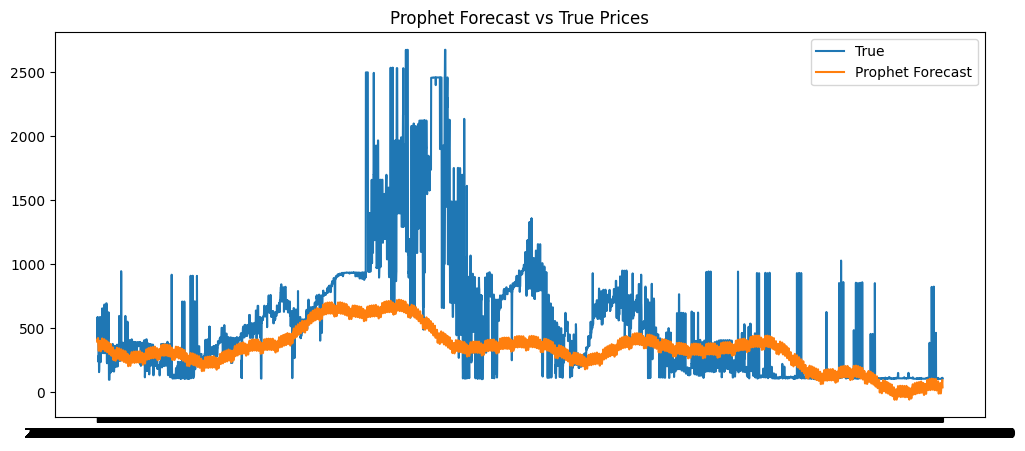

In [19]:
df_prophet = df_prophet.reset_index()[["FECHA_HORA", "PRECIO"]].rename(columns={"FECHA_HORA": "ds", "PRECIO": "y"})

# Train/test split: last 20% as test
train_size = int(len(df_prophet) * 0.8)
train_df, test_df = df_prophet.iloc[:train_size], df_prophet.iloc[train_size:]

# Fit Prophet model
prophet = Prophet(daily_seasonality=True, yearly_seasonality=True, weekly_seasonality=True)
prophet.fit(train_df)

# Forecast over test period
future = prophet.make_future_dataframe(periods=len(test_df), freq="h")
forecast = prophet.predict(future)

# Extract predictions only for test period
pred_prophet = forecast.set_index("ds").loc[test_df["ds"], "yhat"]

# Metrics
mae_p = mean_absolute_error(test_df["y"], pred_prophet)
rmse_p = root_mean_squared_error(test_df["y"], pred_prophet)
r2 = r2_score(test_df["y"], pred_prophet)

print("Prophet Forecasting Results:")
print(f"MAE: {mae_p:.2f}, RMSE: {rmse_p:.2f}, R2: {r2:.2f}")

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(test_df["ds"], test_df["y"], label="True")
plt.plot(test_df["ds"], pred_prophet, label="Prophet Forecast")
plt.legend()
plt.title("Prophet Forecast vs True Prices")
plt.show()

### Ensemble Prophet + XGBoost

XGBoost with Prophet feature:
MAE: 223.12, RMSE: 412.47, R2: 0.32


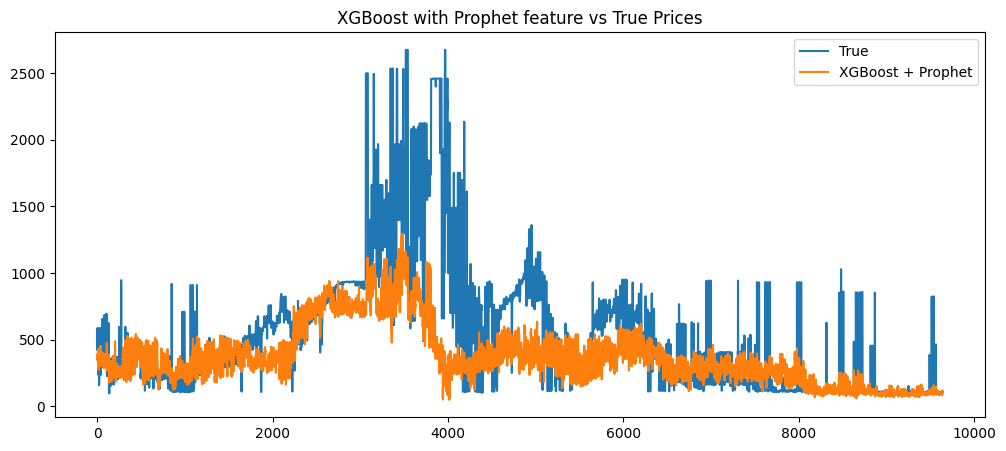

In [20]:
# --- Use Prophet as a feature for XGBoost ---

X_full = df.copy().drop(columns=["FECHA_HORA"])

# Add propehet prediction as a new column
X_full["prophet_yhat"] = forecast.set_index("ds")["yhat"].values

# Define train/test (temporal split)
X_train = X_full.iloc[:train_size].drop(columns=["PRECIO"])
y_train = X_full.iloc[:train_size]["PRECIO"]
X_test = X_full.iloc[train_size:].drop(columns=["PRECIO"])
y_test = X_full.iloc[train_size:]["PRECIO"]

# Train XGBoost
xgb_model = XGBRegressor(random_state=42, n_estimators=500, max_depth=6, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)

# --- Metrics ---
mae = mean_absolute_error(y_test, y_pred_xgb)
rmse = root_mean_squared_error(y_test, y_pred_xgb)
r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost with Prophet feature:")
print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R2: {r2:.2f}")

# --- Paso 5: Graficamos ---
plt.figure(figsize=(12, 5))
plt.plot(y_test.values, label="True")
plt.plot(y_pred_xgb, label="XGBoost + Prophet")
plt.legend()
plt.title("XGBoost with Prophet feature vs True Prices")
plt.show()

## Train and test with lags

In [21]:
# --- Create lag features ---
def create_lags(df, target_col, n_lags=24):
    df_lagged = df.copy()
    for lag in range(1, n_lags+1):
        df_lagged[f"{target_col}_lag{lag}"] = df_lagged[target_col].shift(lag)
    return df_lagged.dropna()

df_lagged = create_lags(df, target_col="PRECIO", n_lags=24)
df_lagged = df_lagged.dropna()

# Features (all except date & target)
X = df_lagged.drop(columns=["FECHA_HORA", "PRECIO"])
y = df_lagged["PRECIO"]

# --- Train/Test split ---
train_size = int(len(X) * 0.8)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

In [22]:
X_train.head()

,TERMICA,HIDRAULICA,COGENERADOR,EOLICA,NIVEL_ENSO,PRECIO_lag1,PRECIO_lag2,PRECIO_lag3,PRECIO_lag4,PRECIO_lag5,...,PRECIO_lag15,PRECIO_lag16,PRECIO_lag17,PRECIO_lag18,PRECIO_lag19,PRECIO_lag20,PRECIO_lag21,PRECIO_lag22,PRECIO_lag23,PRECIO_lag24
24,1608662.67,4585681.98,19184.34,4908.48,1.0,136.71,213.73,213.73,213.73,406.73,...,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71,136.71,72.02
25,1508655.14,4466153.60,19342.06,3836.61,1.0,71.34,136.71,213.73,213.73,213.73,...,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71,136.71
26,1413968.65,4520386.10,20345.52,5343.35,1.0,71.34,71.34,136.71,213.73,213.73,...,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71,127.71
27,1369278.08,4470436.67,21123.41,3942.81,1.0,71.34,71.34,71.34,136.71,213.73,...,136.71,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71,127.71
28,1353049.36,4558570.93,25773.80,2363.15,1.0,71.34,71.34,71.34,71.34,136.71,...,136.71,136.71,136.71,72.02,72.02,72.02,72.02,72.02,72.02,127.71


### XGBoost Forecasting with Lags

XGBoost Forecasting Results:
MAE: 82.37, RMSE: 225.47, R2: 0.80


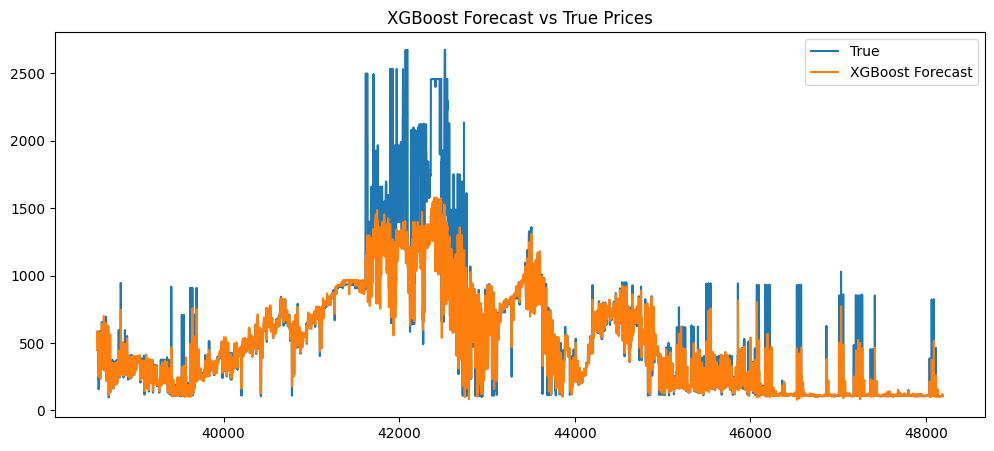

In [23]:
# ===========================================
# XGBoost Forecasting with Lags
# ===========================================

# Train XGBoost
model_xgb = XGBRegressor(objective="reg:squarederror", n_estimators=200, learning_rate=0.1, max_depth=6)
model_xgb.fit(X_train, y_train)

# Predictions
pred_xgb = model_xgb.predict(X_test)

# Metrics
mae_x = mean_absolute_error(y_test, pred_xgb)
rmse_x = root_mean_squared_error(y_test, pred_xgb)
r2_x = r2_score(y_test, pred_xgb)

print("XGBoost Forecasting Results:")
print(f"MAE: {mae_x:.2f}, RMSE: {rmse_x:.2f}, R2: {r2_x:.2f}")

# Plot forecast
plt.figure(figsize=(12, 5))
plt.plot(y_test.index, y_test, label="True")
plt.plot(y_test.index, pred_xgb, label="XGBoost Forecast")
plt.legend()
plt.title("XGBoost Forecast vs True Prices")
plt.show()

### Boosting with lags

In [24]:
models = {
    "XGBoost": XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1),
    "LightGBM": LGBMRegressor(n_estimators=500, learning_rate=0.05, max_depth=-1, random_state=42, n_jobs=-1),
    "CatBoost": CatBoostRegressor(iterations=500, learning_rate=0.05, depth=6, random_state=42, verbose=0)
}

In [25]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    results[name] = {"MAE": mae, "RMSE": rmse, "R2": r2}

df_results = pd.DataFrame(results).T
print(df_results)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005240 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7147
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 29
[LightGBM] [Info] Start training from score 318.370624
                MAE        RMSE        R2
XGBoost   82.044943  223.778370  0.800822
LightGBM  80.672680  222.483981  0.803120
CatBoost  80.507534  217.429770  0.811963


### Boosting with lags (tunning)

In [26]:
# ===================== OBJECTIVES =====================

def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "gamma": trial.suggest_float("gamma", 0, 5),
        "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
        "reg_lambda": trial.suggest_float("reg_lambda", 0, 5)
    }

    model = XGBRegressor(**params, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE


def objective_lgbm(trial):
    params = {
        "n_estimators": trial.suggest_int("n_estimators", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "num_leaves": trial.suggest_int("num_leaves", 20, 300),
        "max_depth": trial.suggest_int("max_depth", 3, 15),
        "min_child_samples": trial.suggest_int("min_child_samples", 10, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0)
    }

    model = LGBMRegressor(**params, random_state=42)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE


def objective_cat(trial):
    params = {
        "iterations": trial.suggest_int("iterations", 200, 1500),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "depth": trial.suggest_int("depth", 3, 12),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1, 10),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0, 1)
    }

    model = CatBoostRegressor(**params, random_state=42, verbose=0)
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    return root_mean_squared_error(y_test, preds)  # RMSE

In [27]:
# ===================== RUN STUDIES =====================

studies = {}
for name, objective in [("XGBoost", objective_xgb), 
                        ("LightGBM", objective_lgbm), 
                        ("CatBoost", objective_cat)]:
    print(f"Running Optuna for {name}...")
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=100)  # puedes subir n_trials si quieres
    studies[name] = study
    print(f"Best params for {name}: {study.best_trial.params}")
    print(f"Best RMSE: {study.best_value:.4f}\n")


# ===================== FINAL EVALUATION =====================

results = {}
best_params = {}
best_scores = {}

for name, study in studies.items():
    if name == "XGBoost":
        model = XGBRegressor(**study.best_trial.params, random_state=42, n_jobs=-1)
    elif name == "LightGBM":
        model = LGBMRegressor(**study.best_trial.params, random_state=42)
    else:
        model = CatBoostRegressor(**study.best_trial.params, random_state=42, verbose=0)

    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    best_params[name] = study.best_trial.params
    best_scores[name] = study.best_value
    
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": root_mean_squared_error(y_test, preds),
        "R2": r2_score(y_test, preds)
    }


[I 2025-09-02 10:51:56,635] A new study created in memory with name: no-name-a47dc58f-411f-4cd5-be55-90967c16ab86


Running Optuna for XGBoost...


[I 2025-09-02 10:52:03,068] Trial 0 finished with value: 221.03394318849053 and parameters: {'n_estimators': 956, 'learning_rate': 0.050187912704926306, 'max_depth': 5, 'subsample': 0.6093297636952253, 'colsample_bytree': 0.9873989115753892, 'gamma': 1.627618361499617, 'reg_alpha': 0.5006899449791652, 'reg_lambda': 1.176074057167641}. Best is trial 0 with value: 221.03394318849053.
[I 2025-09-02 10:52:20,781] Trial 1 finished with value: 227.1322894372748 and parameters: {'n_estimators': 1351, 'learning_rate': 0.04273134954864793, 'max_depth': 8, 'subsample': 0.6808914033983464, 'colsample_bytree': 0.7685082666569345, 'gamma': 3.6879181149007993, 'reg_alpha': 2.075501926112798, 'reg_lambda': 4.564586135643629}. Best is trial 0 with value: 221.03394318849053.
[I 2025-09-02 10:52:26,552] Trial 2 finished with value: 230.1020456168085 and parameters: {'n_estimators': 802, 'learning_rate': 0.09790818904112616, 'max_depth': 6, 'subsample': 0.9265832438112342, 'colsample_bytree': 0.809331610

Best params for XGBoost: {'n_estimators': 1216, 'learning_rate': 0.013914074562388332, 'max_depth': 3, 'subsample': 0.7482763515097837, 'colsample_bytree': 0.8272775062758133, 'gamma': 0.258370115403633, 'reg_alpha': 0.38652105079385785, 'reg_lambda': 0.04800617183895056}
Best RMSE: 211.3798

Running Optuna for LightGBM...
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004880 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7147
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 29
[LightGBM] [Info] Start training from score 318.370624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further

[I 2025-09-02 11:05:56,810] Trial 0 finished with value: 218.14427103710133 and parameters: {'n_estimators': 638, 'learning_rate': 0.07124194607189065, 'num_leaves': 75, 'max_depth': 12, 'min_child_samples': 53, 'subsample': 0.9122130865595662, 'colsample_bytree': 0.748566902192698}. Best is trial 0 with value: 218.14427103710133.


...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

[I 2025-09-02 11:12:08,695] Trial 99 finished with value: 213.43893482275067 and parameters: {'n_estimators': 247, 'learning_rate': 0.11566788345696792, 'num_leaves': 268, 'max_depth': 3, 'min_child_samples': 91, 'subsample': 0.8256785902690225, 'colsample_bytree': 0.9842608769770163}. Best is trial 82 with value: 209.9166811299677.
[I 2025-09-02 11:12:08,699] A new study created in memory with name: no-name-6c42d912-bd3a-4d4b-989a-be23ecbdc7cf


Best params for LightGBM: {'n_estimators': 200, 'learning_rate': 0.05349972144171416, 'num_leaves': 261, 'max_depth': 3, 'min_child_samples': 98, 'subsample': 0.6821146514755965, 'colsample_bytree': 0.9546828466810006}
Best RMSE: 209.9167

Running Optuna for CatBoost...


[I 2025-09-02 11:12:20,189] Trial 0 finished with value: 227.4939013438199 and parameters: {'iterations': 408, 'learning_rate': 0.05155588180483311, 'depth': 8, 'l2_leaf_reg': 5.869765098267834, 'bagging_temperature': 0.3184479371451523}. Best is trial 0 with value: 227.4939013438199.
[I 2025-09-02 11:12:35,177] Trial 1 finished with value: 217.60175610215668 and parameters: {'iterations': 1090, 'learning_rate': 0.027289216272732675, 'depth': 6, 'l2_leaf_reg': 2.778690988944987, 'bagging_temperature': 0.7702446493486003}. Best is trial 1 with value: 217.60175610215668.
[I 2025-09-02 11:14:34,362] Trial 2 finished with value: 239.44107671200854 and parameters: {'iterations': 1255, 'learning_rate': 0.2505098119818322, 'depth': 10, 'l2_leaf_reg': 4.980987079040272, 'bagging_temperature': 0.6348315832703112}. Best is trial 1 with value: 217.60175610215668.
[I 2025-09-02 11:15:08,011] Trial 3 finished with value: 227.14765337776063 and parameters: {'iterations': 1205, 'learning_rate': 0.031

Best params for CatBoost: {'iterations': 638, 'learning_rate': 0.13992130351286705, 'depth': 3, 'l2_leaf_reg': 9.272077978764093, 'bagging_temperature': 0.4387837946143495}
Best RMSE: 211.2797

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.004711 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7147
[LightGBM] [Info] Number of data points in the train set: 38534, number of used features: 29
[LightGBM] [Info] Start training from score 318.370624
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

In [28]:
params_df = pd.DataFrame(best_params).T
params_df["Best_RMSE"] = pd.Series(best_scores)
results_df = pd.DataFrame(results).T

print("\n===== Best Hyperparameters per Model =====")
print(params_df)
print(results_df)


===== Best Hyperparameters per Model =====
          n_estimators  learning_rate  max_depth  subsample  colsample_bytree  \
XGBoost         1216.0       0.013914        3.0   0.748276          0.827278   
LightGBM         200.0       0.053500        3.0   0.682115          0.954683   
CatBoost           NaN       0.139921        NaN        NaN               NaN   

            gamma  reg_alpha  reg_lambda  num_leaves  min_child_samples  \
XGBoost   0.25837   0.386521    0.048006         NaN                NaN   
LightGBM      NaN        NaN         NaN       261.0               98.0   
CatBoost      NaN        NaN         NaN         NaN                NaN   

          iterations  depth  l2_leaf_reg  bagging_temperature   Best_RMSE  
XGBoost          NaN    NaN          NaN                  NaN  211.379774  
LightGBM         NaN    NaN          NaN                  NaN  209.916681  
CatBoost       638.0    3.0     9.272078             0.438784  211.279653  
                MAE       

### Baseline models with lag

In [29]:
# Entrenar cada modelo base con cross-validation
results_base = {}

# Define temporal validation with 5 splits
tscv = TimeSeriesSplit(n_splits=5)

for name, model in baseline_models.items():
    scores = cross_validate(model, X, y, cv=tscv, scoring=scoring, n_jobs=-1)
    results_base[name] = {
        metric: np.mean(scores[f"test_{metric}"]) for metric in scoring.keys()
    }

# Mostrar resultados
results_base_df = pd.DataFrame(results_base).T
print(results_base_df)

                         r2         mae           mse        rmse
Linear Regression  0.950588   25.427625   4504.826404   55.104207
Ridge              0.950588   25.427527   4504.824574   55.104138
Lasso              0.951665   25.198593   4498.723397   54.943479
ElasticNet         0.951583   25.227380   4500.222416   54.961336
Decision Tree      0.625168   79.464838  47581.712215  167.482934
Random Forest      0.804342   57.239871  26826.405279  122.106393
Gradient Boosting  0.838649   51.949232  27459.538223  116.912668
SVR               -0.084214  183.050140  89520.531435  255.285711
KNN                0.062167  155.435138  68845.667729  227.711582


### Baseline models (linear) with lag (tunning)

In [30]:
# ========================
# Setting
# ========================

# Split
tscv = TimeSeriesSplit(n_splits=5)

# Scorers
scoring = {
    "r2": make_scorer(r2_score),
    "mae": make_scorer(mean_absolute_error),
    "rmse": make_scorer(lambda y, y_pred: root_mean_squared_error(y, y_pred))
}

# ========================
# Linear models → GridSearchCV
# ========================

linear_grids = {
    "Linear Regression": (LinearRegression(), {}),
    "Ridge": (Ridge(), {"alpha": [0.01, 0.1, 1, 10, 100]}),
    "Lasso": (Lasso(max_iter=5000), {"alpha": [0.001, 0.01, 0.1, 1, 10]}),
    "ElasticNet": (ElasticNet(max_iter=5000), {
        "alpha": [0.001, 0.01, 0.1, 1, 10],
        "l1_ratio": [0.1, 0.5, 0.9]
    }),
}

In [31]:
results = {}

for name, (model, grid) in linear_grids.items():
    search = GridSearchCV(
        model,
        param_grid=grid,
        scoring="neg_root_mean_squared_error",
        cv=tscv,
        n_jobs=-1
    )
    search.fit(X, y)
    best_model = search.best_estimator_

    # Cross-validate with multiple metrics
    scores = cross_val_score(best_model, X, y, cv=tscv, scoring="r2")
    r2 = scores.mean()
    scores_mae = cross_val_score(best_model, X, y, cv=tscv, scoring="neg_mean_absolute_error")
    mae = -scores_mae.mean()
    scores_rmse = cross_val_score(best_model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    rmse = -scores_rmse.mean()

    results[name] = {
        "Best Params": search.best_params_,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

df_results = pd.DataFrame(results).T
df_results

,Best Params,R2,MAE,RMSE
Linear Regression,{},0.950588,25.427625,55.104207
Ridge,{'alpha': 100},0.950638,25.41819,55.097504
Lasso,{'alpha': 10},0.951756,25.130964,54.894781
ElasticNet,"{'alpha': 10, 'l1_ratio': 0.9}",0.951768,25.136057,54.895601


In [32]:
#Best Params	R2	MAE	RMSE
#Linear Regression	{}	0.948861	26.688284	55.639576
#Ridge	{'alpha': 100}	0.949168	26.595779	55.589767
#Lasso	{'alpha': 0.1}	0.949673	26.3468	55.473241
#ElasticNet	{'alpha': 0.1, 'l1_ratio': 0.9}	0.949626	26.345297	55.47959

### Baseline models (non-linear) with lag (tunning)

In [33]:
# ========================
# Non-linear models → Optuna
# ========================

# Split
tscv = TimeSeriesSplit(n_splits=5)

def optuna_objective(trial, model_name):
    
    if model_name == "Decision Tree":
        model = DecisionTreeRegressor(
            max_depth=trial.suggest_int("max_depth", 2, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            random_state=42
        )

    elif model_name == "Random Forest":
        model = RandomForestRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000),
            max_depth=trial.suggest_int("max_depth", 2, 20),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 20),
            max_features=trial.suggest_categorical("max_features", ["sqrt", "log2", None]),
            n_jobs=-1, random_state=42
        )

    elif model_name == "Gradient Boosting":
        model = GradientBoostingRegressor(
            n_estimators=trial.suggest_int("n_estimators", 100, 1000),
            learning_rate=trial.suggest_float("learning_rate", 0.001, 0.2, log=True),
            max_depth=trial.suggest_int("max_depth", 2, 10),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            random_state=42
        )

    # CV RMSE
    scores = cross_val_score(model, X, y, cv=tscv, scoring="neg_root_mean_squared_error")
    return -scores.mean()

In [34]:
nonlinear_models = ["Decision Tree", "Random Forest", "Gradient Boosting"]

In [35]:
nonlinear_results = {}

for name in nonlinear_models:
    study = optuna.create_study(direction="minimize")
    study.optimize(lambda trial: optuna_objective(trial, name), n_trials=30, n_jobs=-1)

    best_params = study.best_params

    # Entrenar con los mejores parámetros
    if name == "Decision Tree":
        best_model = DecisionTreeRegressor(**best_params, random_state=42)
    elif name == "Random Forest":
        best_model = RandomForestRegressor(**best_params, n_jobs=-1, random_state=42)
    elif name == "Gradient Boosting":
        best_model = GradientBoostingRegressor(**best_params, random_state=42)

    # Cross-validate with metrics
    r2 = cross_val_score(best_model, X, y, cv=tscv, scoring="r2").mean()
    mae = -cross_val_score(best_model, X, y, cv=tscv, scoring="neg_mean_absolute_error").mean()
    rmse = -cross_val_score(best_model, X, y, cv=tscv, scoring="neg_root_mean_squared_error").mean()

    nonlinear_results[name] = {
        "Best Params": best_params,
        "R2": r2,
        "MAE": mae,
        "RMSE": rmse
    }

df_nonlinear_results = pd.DataFrame(nonlinear_results).T
df_nonlinear_results

[I 2025-09-02 11:45:38,888] A new study created in memory with name: no-name-a38390eb-9b6d-46f3-8e91-04034fc8e990
[I 2025-09-02 11:45:43,569] Trial 8 finished with value: 123.62691204575495 and parameters: {'max_depth': 3, 'min_samples_split': 17}. Best is trial 8 with value: 123.62691204575495.
[I 2025-09-02 11:45:43,712] Trial 4 finished with value: 123.62691204575495 and parameters: {'max_depth': 3, 'min_samples_split': 7}. Best is trial 8 with value: 123.62691204575495.
[I 2025-09-02 11:45:48,822] Trial 14 finished with value: 128.14583256413684 and parameters: {'max_depth': 6, 'min_samples_split': 12}. Best is trial 8 with value: 123.62691204575495.
[I 2025-09-02 11:45:49,634] Trial 6 finished with value: 151.59564255429814 and parameters: {'max_depth': 7, 'min_samples_split': 18}. Best is trial 8 with value: 123.62691204575495.
[I 2025-09-02 11:45:50,078] Trial 5 finished with value: 154.06822417441174 and parameters: {'max_depth': 7, 'min_samples_split': 4}. Best is trial 8 with

,Best Params,R2,MAE,RMSE
Decision Tree,"{'max_depth': 5, 'min_samples_split': 17}",0.864693,45.717869,97.387668
Random Forest,"{'n_estimators': 720, 'max_depth': 6, 'min_sam...",0.836184,52.829929,107.956333
Gradient Boosting,"{'n_estimators': 709, 'learning_rate': 0.00946...",0.870391,43.380018,103.231068


In [36]:
nonlinear_results

{'Decision Tree': {'Best Params': {'max_depth': 5, 'min_samples_split': 17},
  'R2': 0.864693164216259,
  'MAE': 45.717869211618314,
  'RMSE': 97.38766786774318},
 'Random Forest': {'Best Params': {'n_estimators': 720,
   'max_depth': 6,
   'min_samples_split': 11,
   'max_features': 'sqrt'},
  'R2': 0.8361839262218392,
  'MAE': 52.82992903532143,
  'RMSE': 107.95633252150182},
 'Gradient Boosting': {'Best Params': {'n_estimators': 709,
   'learning_rate': 0.00946215428904337,
   'max_depth': 2,
   'subsample': 0.6748584191262215},
  'R2': 0.8703908041376645,
  'MAE': 43.38001757775552,
  'RMSE': 103.23106841296396}}

In [37]:
#Best Params	R2	MAE	RMSE
#Linear Regression	{}	0.948861	26.688284	55.639576
#Ridge	{'alpha': 100}	0.949168	26.595779	55.589767
#Lasso	{'alpha': 0.1}	0.949673	26.3468	55.473241
#ElasticNet	{'alpha': 0.1, 'l1_ratio': 0.9}	0.949626	26.345297	55.47959
#Decision Tree	{'max_depth': 5, 'min_samples_split': 8}	0.852894	47.07064	98.828144
#Random Forest	{'n_estimators': 380, 'max_depth': 5, 'min_samples_split': 7,'max_features': None}	0.875931	44.651063	97.202218

In [38]:
# Random forest
#{'Best Params': {'n_estimators': 380,
#  'max_depth': 5,
#  'min_samples_split': 7,
#  'max_features': None},
# 'R2': 0.8759310854350622,
# 'MAE': 44.6510629713005,
# 'RMSE': 97.20221800266624}

In [39]:
#{'Decision Tree': {'Best Params': {'max_depth': 5, 'min_samples_split': 17},
#  'R2': 0.8528940981487452,
#  'MAE': 47.07063996534437,
#  'RMSE': 98.82814400209875},
# 'Random Forest': {'Best Params': {'n_estimators': 407,
#   'max_depth': 4,
#   'min_samples_split': 16,
#   'max_features': None},
#  'R2': 0.8626976844486611,
#  'MAE': 47.776218604543374,
#  'RMSE': 101.92848807043003},
# 'Gradient Boosting': {'Best Params': {'n_estimators': 710,
#   'learning_rate': 0.004824184299163144,
#   'max_depth': 2,
#   'subsample': 0.54752888994856},
#  'R2': 0.8518062305030419,
#  'MAE': 50.53916588389959,
#  'RMSE': 103.0669818471433}}

results 0 with value: 98.0681054649906.

### Other robust models

In [40]:
# Nuevos modelos robustos
new_models = {
    "Extra Trees": ExtraTreesRegressor(n_jobs=-1, random_state=42),
    "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42),
    "MLP Regressor": MLPRegressor(random_state=42, max_iter=500)
}

In [41]:
# Evaluación
results_new = {}

scoring = {
    "r2": "r2",
    "mae": "neg_mean_absolute_error",
    "mse": "neg_mean_squared_error",
    "rmse": "neg_root_mean_squared_error"
}

for name, model in new_models.items():
    pipe = Pipeline(steps=[("model", model)])
    scores = cross_validate(pipe, X, y, cv=5, scoring=scoring, n_jobs=-1)
    results_new[name] = {metric: abs(scores[f"test_{metric}"].mean()) if metric != "r2"
                         else scores[f"test_{metric}"].mean()
                         for metric in scoring.keys()}

df_results_new = pd.DataFrame(results_new).T
print(df_results_new)

                               r2          mae           mse         rmse
Extra Trees              0.919118    32.804459  1.227589e+04    76.222470
Hist Gradient Boosting   0.923349    31.940784  1.112000e+04    74.042318
MLP Regressor          -25.075950  1144.104770  2.406163e+06  1214.028057


<hr>

## Long short-term memory (LSTM)

In [42]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [43]:
# Numerical variables
print(numeric_features)

['TERMICA', 'HIDRAULICA', 'COGENERADOR', 'EOLICA']


In [44]:
# Scale numerical variables

# ============================
# 1. Prepare data
# ============================

scaler = MinMaxScaler()
df_scaled = df.copy().drop(columns=["FECHA_HORA"])
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])
df_scaled

,PRECIO,TERMICA,HIDRAULICA,COGENERADOR,EOLICA,NIVEL_ENSO
0,72.02,0.363247,0.269862,0.189648,0.100633,1.0
1,136.71,0.310187,0.286300,0.191136,0.082356,1.0
2,127.71,0.278933,0.283414,0.170337,0.061953,1.0
3,127.71,0.263346,0.274959,0.168444,0.071108,1.0
4,127.71,0.276951,0.252457,0.165776,0.058972,1.0
...,...,...,...,...,...,...
48187,112.55,0.190143,0.849097,0.578630,0.547735,0.0
48188,112.55,0.191153,0.826843,0.613528,0.549004,0.0
48189,106.25,0.204237,0.784387,0.624925,0.546028,0.0
48190,105.55,0.209577,0.727481,0.651119,0.546691,0.0


In [45]:
# ============================
# 2. Create sequences for LSTM
# ============================

def create_sequences(data, target_col="PRECIO", window_size=24):
    X, y = [], []
    target_idx = data.columns.get_loc(target_col)
    
    for i in range(len(data) - window_size):
        X.append(data.iloc[i:(i + window_size)].values)
        y.append(data.iloc[i + window_size, target_idx])
    
    return np.array(X), np.array(y)

look_back = 48
X, y = create_sequences(df_scaled, target_col="PRECIO", window_size=look_back)

print("X shape:", X.shape)  # (samples, timesteps, features)
print("y shape:", y.shape)

X shape: (48144, 48, 6)
y shape: (48144,)


In [46]:
# ============================
# 3. Train-Test split (time series, not random)
# ============================
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [47]:
# ============================
# 4. Model construction (Multivariate - Single step)
# ============================

n_features = X_train.shape[2]  # Número total de variables predictoras

model = Sequential()
model.add(LSTM(128, activation='tanh', return_sequences=True, input_shape=(look_back, n_features)))
model.add(Dropout(0.2))
model.add(LSTM(64, activation='tanh', return_sequences=False))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))  # salida para regresión

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Early stopping (para evitar sobreentrenamiento)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

model.summary()



Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 lstm (LSTM)                 (None, 48, 128)           69120     
                                                                 
 dropout (Dropout)           (None, 48, 128)           0         
                                                                 
 lstm_1 (LSTM)               (None, 64)                49408     
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense (Dense)               (None, 32)                2080      
                                                                 
 dense_1 (Dense)             (None, 1)                 33        
                                                                 
Total params: 120641 (471.25 KB)
Trainable params: 120

In [48]:
# ============================
# 5. Train model

# ============================

history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


482/482 [==============================] - 106s 202ms/step - loss: 38651.6328 - mae: 138.4789 - val_loss: 216615.1250 - val_mae: 382.1970
Epoch 2/50
482/482 [==============================] - 99s 206ms/step - loss: 5696.0981 - mae: 38.7746 - val_loss: 71595.6641 - val_mae: 176.5273
Epoch 3/50
482/482 [==============================] - 1082s 2s/step - loss: 2264.3113 - mae: 27.5880 - val_loss: 42397.2148 - val_mae: 127.6236
Epoch 4/50
482/482 [==============================] - 97s 202ms/step - loss: 1763.1758 - mae: 25.0040 - val_loss: 31322.4199 - val_mae: 118.9706
Epoch 5/50
482/482 [==============================] - 97s 202ms/step - loss: 1588.4688 - mae: 23.6174 - val_loss: 26475.0449 - val_mae: 101.2713
Epoch 6/50
482/482 [==============================] - 97s 201ms/step - loss: 1512.3278 - mae: 22.7793 - val_loss: 24488.1719 - val_mae: 94.4603
Epoch 7/50
482/482 [==============================] - 97s 201ms/step - loss: 1491.2231 - mae: 22.5372 - val_loss: 20986.5078 -

In [49]:

# ============================
# 6. Evaluation
# ============================

y_pred = model.predict(X_test)

y_test_inv = y_test
y_pred_inv = y_pred.flatten()

rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae = mean_absolute_error(y_test_inv, y_pred_inv)
r2 = r2_score(y_test_inv, y_pred_inv)

print(f"R2: {r2}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")

301/301 [==============================] - 14s 40ms/step
R2: 0.5909757734392218, RMSE: 320.7630, MAE: 117.9055


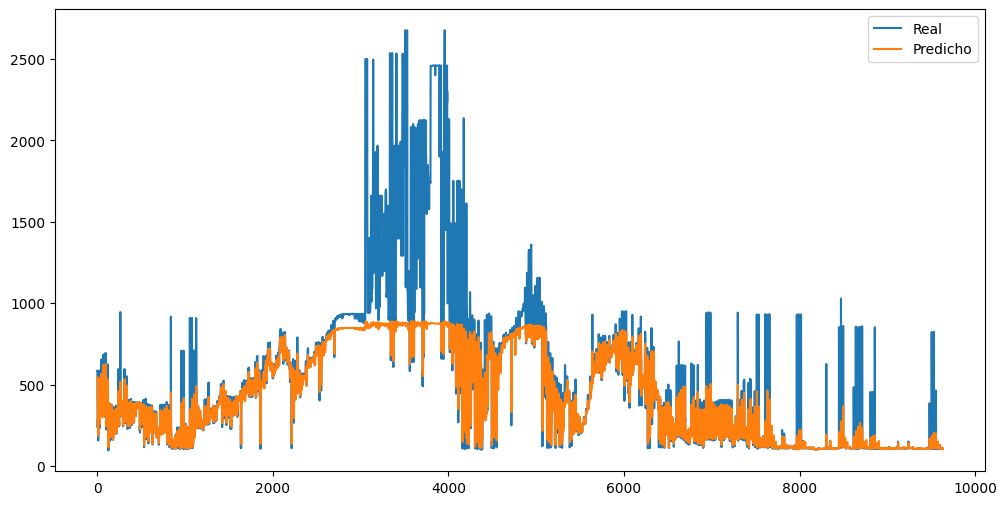

In [50]:
# ============================
# 7. Graphic
# ============================

plt.figure(figsize=(12,6))
plt.plot(y_test_inv, label="Real")
plt.plot(y_pred_inv, label="Predicho")
plt.legend()
plt.show()